In [1]:
pip install dynatab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 86.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.


In [3]:
from dynatab import DynaTabClassifier, DFOConfig, TrainConfig, LossConfig

print(DynaTabClassifier, DFOConfig, TrainConfig, LossConfig)

<class 'dynatab.estimator.DynaTabClassifier'> <class 'dynatab.dfo.DFOConfig'> <class 'dynatab.trainer.TrainConfig'> <class 'dynatab.trainer.LossConfig'>


In [4]:
from importlib.metadata import version

print("dynatab version:", version("dynatab"))

dynatab version: 0.1.0


In [5]:
pip show dynatab

Name: dynatab
Version: 0.1.0
Summary: DynaTab: Dynamic Feature Ordering as Neural Rewiring for High-Dimensional Tabular Data
Home-page: https://github.com/zadid6pretam/DynaTab
Author: 
Author-email: Al Zadid Sultan Bin Habib <your_email@example.com>
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: kmeans_gpu, matplotlib, numpy, pandas, scikit-learn, scipy, torch
Required-by: 


X shape: (120, 20)
y distribution: [58 62]

=== Fitting DynaTabClassifier on toy data ===
Epoch 001 | loss=0.736377
Epoch 002 | loss=0.655865
Epoch 003 | loss=0.633722
Test metrics: {'acc': 0.44999998807907104}

=== Running IDF analysis on the same X ===
mean_idf: 0.9
auc_cumvar_vs_idf: 0.19073766824395708
loss: 0.0
complexity_score: 1.1968509267602934
foe: 1.2345679012345678


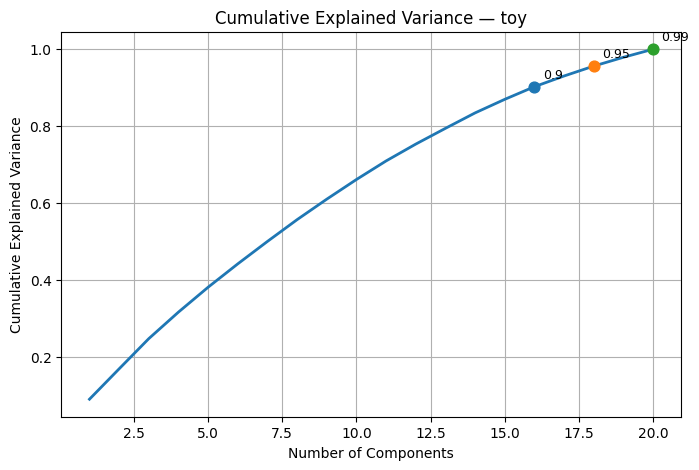

In [6]:
import numpy as np
import pandas as pd

from dynatab import DynaTabClassifier, DFOConfig, TrainConfig, LossConfig
from dynatab.idf_analyzer import TabularIDFAnalyzer

# -----------------------------
# 1) Synthetic binary dataset
# -----------------------------
n_samples = 120
n_features = 20

rng = np.random.RandomState(42)
X = pd.DataFrame(
    rng.normal(size=(n_samples, n_features)),
    columns=[f"f{i}" for i in range(n_features)],
)
# Simple non-trivial label: sign of a linear projection + noise
w = rng.normal(size=(n_features,))
logits = X.values @ w + 0.5 * rng.normal(size=n_samples)
y = (logits > 0).astype(int)

print("X shape:", X.shape)
print("y distribution:", np.bincount(y))

# -----------------------------
# 2) DynaTab configs
# -----------------------------
dfo_cfg = DFOConfig(
    metric="variance",   # simple + fast
    num_clusters=2,
    order="ascending",
    mutation_prob=0.0,
    tolerance=1e-3,
    seed=42,
)

train_cfg = TrainConfig(
    epochs=3,            # very small, just to test that it runs
    lr=1e-3,
    batch_size=32,
    print_every=1,
)

loss_cfg = LossConfig(
    loss_mode="standard",  # simplest
    lambda_disp=0.0,
    lambda_global=0.0,
)

clf = DynaTabClassifier(
    task="binary",
    backbone="Transformer",      # any backbone you wired up: "Transformer", "LSTM", "DAE", "Mamba"
    embedding_dim=32,            # small to keep it light
    backbone_kwargs={
        "d_model": 64,
        "nhead": 2,
        "num_layers": 1,
        "dropout": 0.1,
    },
    dfo_cfg=dfo_cfg,
    train_cfg=train_cfg,
    loss_cfg=loss_cfg,
    eval_metrics=["acc"],
    device=None,                 # auto-select CUDA if available
    standardize=True,            # train-only impute + standardize
)

# -----------------------------
# 3) Fit + evaluate
# -----------------------------
# Use first 100 as "train", last 20 as "test" just for a quick check
X_train, X_test = X.iloc[:100], X.iloc[100:]
y_train, y_test = y[:100], y[100:]

print("\n=== Fitting DynaTabClassifier on toy data ===")
clf.fit(X_train, y_train)

metrics = clf.score(X_test, y_test, metrics=["acc"])
print("Test metrics:", metrics)

# -----------------------------
# 4) Quick IDF / complexity check
# -----------------------------
print("\n=== Running IDF analysis on the same X ===")
analyzer = TabularIDFAnalyzer(
    variance_thresholds=(0.90, 0.95, 0.99),
    scale="zscore",
    zscore_axis=0,
    impute="mean",
)

idf_res = analyzer.analyze(X, dataset_name="toy")
print("mean_idf:", idf_res.mean_idf)
print("auc_cumvar_vs_idf:", idf_res.auc_cumvar_vs_idf)
print("loss:", idf_res.loss)
print("complexity_score:", idf_res.complexity_score)
print("foe:", idf_res.foe)

# If you want to see a plot in Colab:
import matplotlib.pyplot as plt
TabularIDFAnalyzer.plot_cumulative_variance_curve(idf_res)
plt.show()